In [2]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [3]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA')
from ESMCBA.imports import *
from ESMCBA import graph_utils

In [27]:
directory = '/global/scratch/users/sergiomar10/logs/ESMC_Pretrain_logs'
csv_files = glob.glob(os.path.join(directory, '*.csv'))
data = []

for file in csv_files:
    if os.path.getsize(file) > 0:
        try:
            df = pd.read_csv(file)
            base = os.path.basename(file)
            # Remove the file extension and split by underscore
            name_parts = os.path.splitext(base)[0].split('_')
            # Expected filename parts:
            # [0]: "training"
            # [1]: "log"
            # [2]: "ESMMASK"
            # [3]: encoding           (e.g., "HLA" or "epitope")
            # [4]: "FT"
            # [5]: blocks_unfrozen    (e.g., "25")
            # [6]: base_block_lr      (e.g., "0.0001")
            # [7]: regression_block_lr (e.g., "0.001")
            # [8]: "AUG"
            # [9]: num_augmentations  (e.g., "6")
            # [10]: HLA allele        (e.g., "HLAA3001")
            # [11]: (optional, e.g., replicate index)
            if len(name_parts) >= 11:
                encoding = name_parts[3]
                blocks_unfrozen = int(name_parts[5])
                base_block_lr = float(name_parts[6])
                regression_block_lr = float(name_parts[7])
                num_augmentations = int(name_parts[9])
                hla_allele = name_parts[10]
            else:
                encoding = 'Unknown'
                blocks_unfrozen = None
                base_block_lr = None
                regression_block_lr = None
                num_augmentations = None
                hla_allele = 'Unknown'
                
            max_val_acc = df['Val Acc'].max() if 'Val Acc' in df.columns else None
            
            data.append({
                'file': file,
                'filename': base,
                'encoding': encoding,
                'blocks_unfrozen': blocks_unfrozen,
                'base_block_lr': base_block_lr,
                'regression_block_lr': regression_block_lr,
                'num_augmentations': num_augmentations,
                'HLA_allele': hla_allele,
                'max_val_acc': max_val_acc
            })
        except Exception as e:
            print(f"Error reading {file}: {e}")
            continue

df_summary = pd.DataFrame(data)


In [52]:
df_summary['HLA_allele'].value_counts().head(10)

HLA_allele
HLAB5701    73
HLAB5101    71
HLAB3901    69
HLAA3001    66
HLAA0101    66
HLAA6801    64
HLAB1501    62
HLAB1801    62
HLAB4402    61
HLAB0801    61
Name: count, dtype: int64

In [42]:
df_summary['BU_HLA'] = df_summary['base_block_lr'].astype(str) + ' + ' + df_summary['encoding'].astype(str)

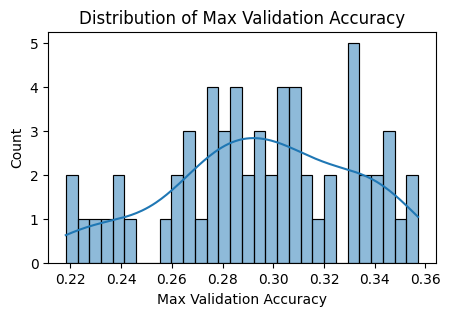

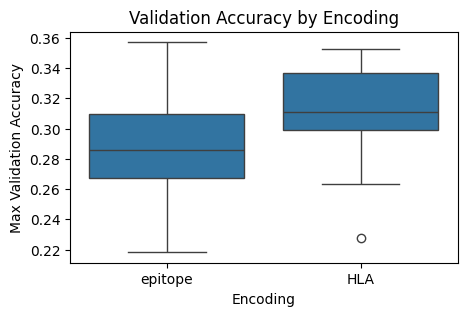

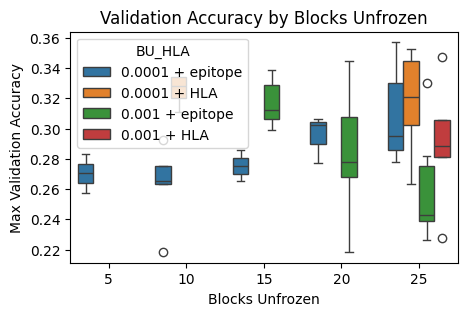

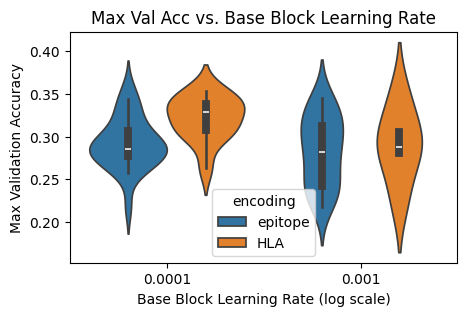

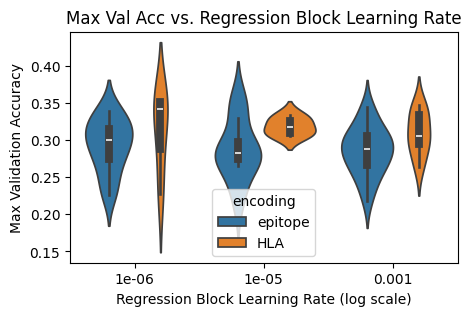

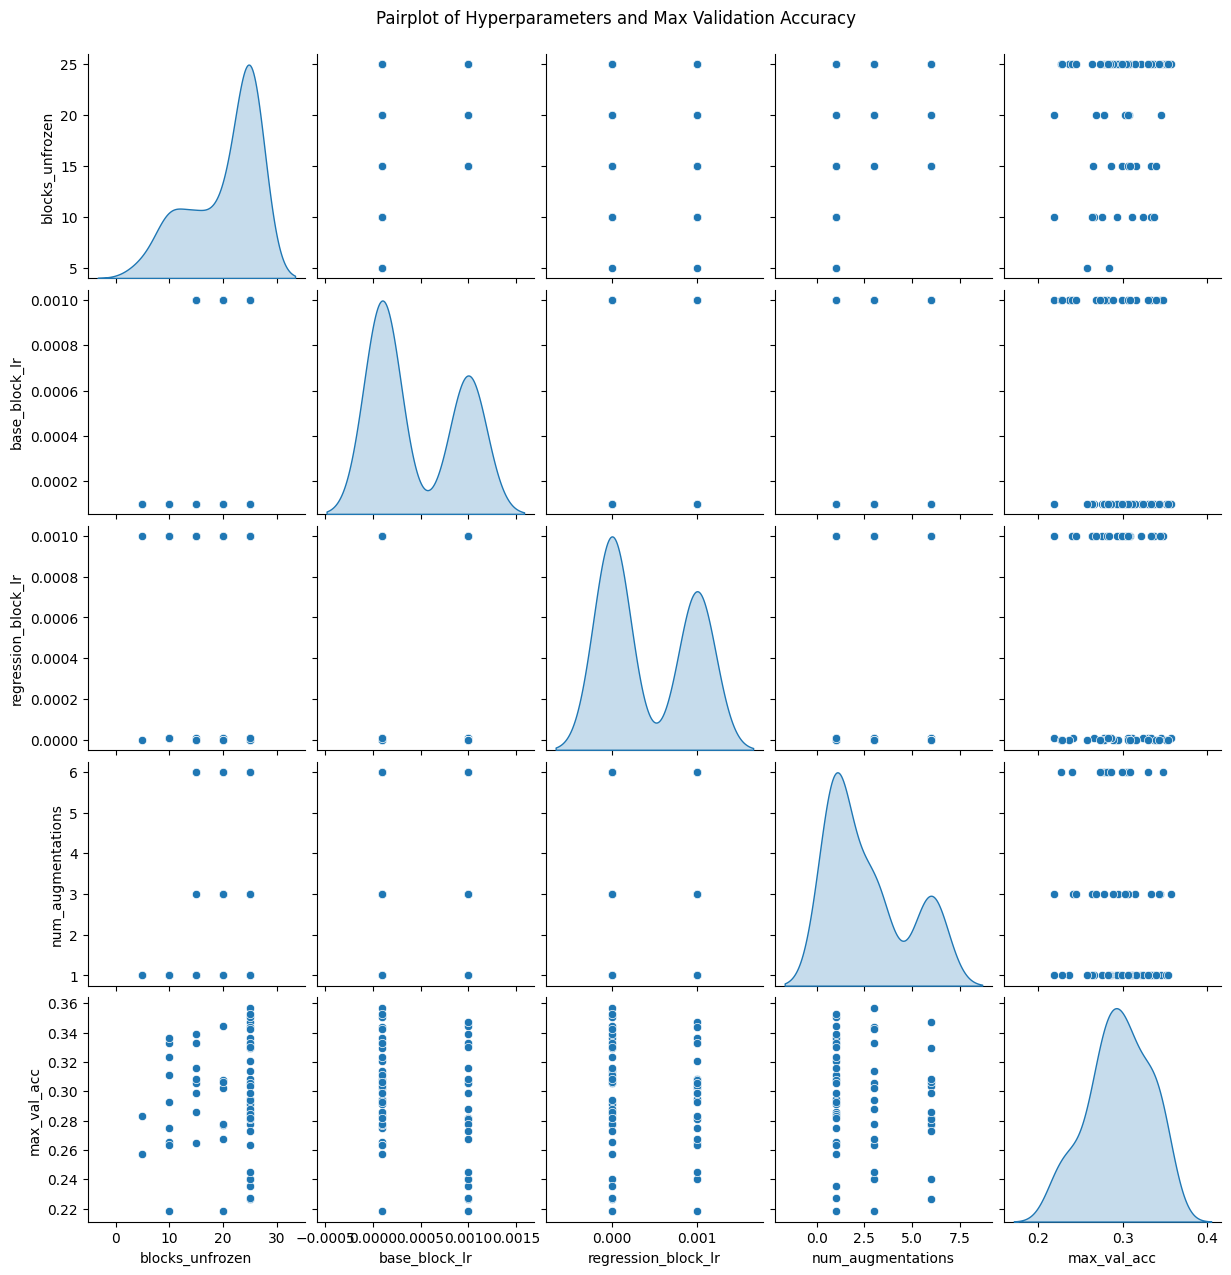

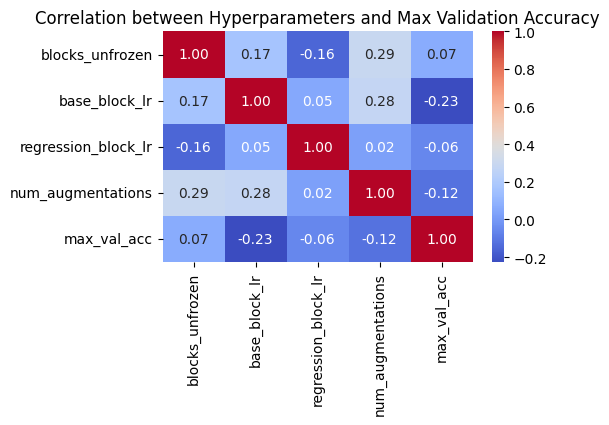

In [53]:
df_summary_subset = df_summary[df_summary['HLA_allele'] == 'HLAB4402' ]

# 1. Histogram of max_val_acc
plt.figure(figsize=(5, 3))
sns.histplot(df_summary_subset['max_val_acc'], bins=30, kde=True)
plt.title("Distribution of Max Validation Accuracy")
plt.xlabel("Max Validation Accuracy")
plt.ylabel("Count")
plt.show()

# 2. Boxplot: Max Val Acc by Encoding
plt.figure(figsize=(5, 3))
sns.boxplot(x='encoding', y='max_val_acc', data=df_summary_subset)
plt.title("Validation Accuracy by Encoding")
plt.xlabel("Encoding")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 3. Boxplot: Max Val Acc by Number of Unfrozen Blocks (if only a few distinct values)
plt.figure(figsize=(5, 3))
sns.boxplot(x='blocks_unfrozen', y='max_val_acc', hue='BU_HLA', data=df_summary_subset)
plt.title("Validation Accuracy by Blocks Unfrozen")
plt.xlabel("Blocks Unfrozen")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 4. Scatter Plot: Base Block LR vs. Max Val Acc (using log scale for lr)
plt.figure(figsize=(5, 3))
sns.violinplot(x='base_block_lr', y='max_val_acc', hue='encoding', data=df_summary_subset)
# plt.xscale('log')
plt.title("Max Val Acc vs. Base Block Learning Rate")
plt.xlabel("Base Block Learning Rate (log scale)")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 5. Scatter Plot: Regression Block LR vs. Max Val Acc (using log scale)
plt.figure(figsize=(5, 3))
sns.violinplot(x='regression_block_lr', y='max_val_acc', hue='encoding', data=df_summary_subset)
# plt.xscale('log')
plt.title("Max Val Acc vs. Regression Block Learning Rate")
plt.xlabel("Regression Block Learning Rate (log scale)")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 6. Pairplot: Visualize all hyperparameters vs max_val_acc
selected_cols = ['blocks_unfrozen', 'base_block_lr', 'regression_block_lr', 'num_augmentations', 'max_val_acc']
sns.pairplot(df_summary_subset[selected_cols], diag_kind='kde')
plt.suptitle("Pairplot of Hyperparameters and Max Validation Accuracy", y=1.02)
plt.show()

# 7. Correlation Heatmap: Numerical hyperparameters and performance
corr_cols = ['blocks_unfrozen', 'base_block_lr', 'regression_block_lr', 'num_augmentations', 'max_val_acc']
corr_matrix = df_summary_subset[corr_cols].corr()
plt.figure(figsize=(5, 3))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Hyperparameters and Max Validation Accuracy")
plt.show()


In [109]:
perp_set = pd.read_csv('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_03042025_perplexity/ESMMASK_epitope_FT_15_0.001_5e-05_AUG_3_HLAB5801_2_per_token_metrics.csv')

In [110]:
perp_set_2 = pd.read_csv('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_03042025_perplexity/ESMMASK_epitope_FT_20_0.001_5e-05_AUG_3_HLAB5801_2_per_token_metrics.csv')

In [111]:
df_merged = pd.merge(
    perp_set, 
    perp_set_2, 
    on=['epitope', 'position'], 
    how='inner',
    suffixes=('_model1', '_model2') ## 5e-05 1e-06
)


In [112]:
df_grouped = df_merged.groupby('epitope').agg({
    'token_nll_model1': 'mean',
    'token_nll_model2': 'mean'
}).reset_index()

# Compute pseudo-perplexity for each model as exp(mean NLL)
df_grouped['ppl_model1'] = np.exp(df_grouped['token_nll_model1'])
df_grouped['ppl_model2'] = np.exp(df_grouped['token_nll_model2'])

# Compute the difference in perplexity (Model1 - Model2)
df_grouped['delta'] = df_grouped['ppl_model1'] - df_grouped['ppl_model2']

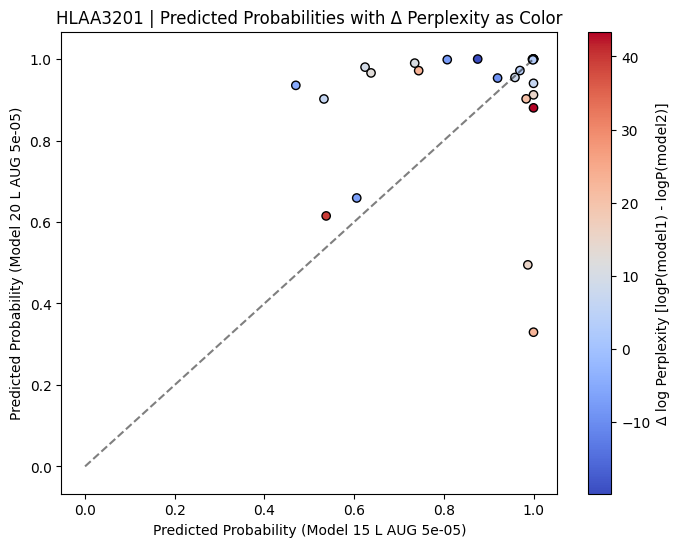

In [114]:

df_merged['log_ppl_model1'] = df_merged['token_nll_model1']  # since perplexity = exp(NLL)
df_merged['log_ppl_model2'] = df_merged['token_nll_model2']

df_merged['delta_log_ppl'] = df_merged['log_ppl_model1'] - df_merged['log_ppl_model2']

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_merged['predicted_prob_model1'],
    df_merged['predicted_prob_model2'],
    c=df_merged['delta_log_ppl'],
    cmap='coolwarm',
    edgecolor='k'
)
cbar = plt.colorbar(scatter)
cbar.set_label("Δ log Perplexity [logP(model1) - logP(model2)]")

# Dynamically determine axis limits based on data
x_min = df_merged['predicted_prob_model1'].min()
x_max = df_merged['predicted_prob_model1'].max()
y_min = df_merged['predicted_prob_model2'].min()
y_max = df_merged['predicted_prob_model2'].max()

# Add a margin of 10% of the range to each axis
x_margin = (x_max - x_min) * 0.1
y_margin = (y_max - y_min) * 0.1
plt.xlim(0 - x_margin, 1 + x_margin)
plt.ylim(0 - y_margin, 1 + y_margin)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

plt.xlabel("Predicted Probability (Model 15 L AUG 5e-05)")
plt.ylabel("Predicted Probability (Model 20 L AUG 5e-05)")
plt.title("HLAA3201 | Predicted Probabilities with Δ Perplexity as Color")
plt.show()


In [5]:
sorted_acuraccies = []
for file_name in glob.glob('/global/scratch/users/sergiomar10/models/ESMC_Pretrain/*/*.pt'):
    try:
        file_name = file_name.split('/')[-1].replace('.pt', '.csv')
        file_name = f'/global/scratch/users/sergiomar10/data/ESMC_Pretrain/{file_name}'
        eval_df = pd.read_csv(file_name)
        eval_df = eval_df[eval_df['original_aa'] != '<eos>']
        eval_df['correct'] = eval_df['original_aa'] == eval_df['predicted_aa']
        size_of_eval_set = len(eval_df)
        creation_time = os.path.getctime(file_name)
        creation_date = datetime.datetime.fromtimestamp(creation_time)
        acuraccy = len(eval_df[eval_df['correct'] == 1]) / len(eval_df)
        sorted_acuraccies.append([file_name, creation_date, size_of_eval_set, acuraccy])
    except:
        print(file_name)

eval_acc = pd.DataFrame(sorted_acuraccies, columns=['file', 'date', 'eval_set_size', 'accuracy'])
eval_acc = eval_acc[eval_acc['accuracy'] < 0.8]

/global/scratch/users/sergiomar10/data/ESMC_Pretrain/ESMMASK_HLA_FT_10_0.0001_0.001_AUG_1_HLAA0101_3.csv
/global/scratch/users/sergiomar10/data/ESMC_Pretrain/ESMMASK_epitope_FT_5_0.001_0.001_AUG_1_HLAA0101_1.csv
/global/scratch/users/sergiomar10/data/ESMC_Pretrain/ESMMASK_HLA_FT_10_0.0001_0.001_AUG_1_HLAA0301_2.csv
/global/scratch/users/sergiomar10/data/ESMC_Pretrain/ESMMASK_epitope_FT_5_0.001_1e-06_AUG_6_HLAA0301_2.csv
/global/scratch/users/sergiomar10/data/ESMC_Pretrain/ESMMASK_HLA_FT_10_0.0001_0.001_AUG_1_HLAA0301_3.csv
/global/scratch/users/sergiomar10/data/ESMC_Pretrain/ESMMASK_HLA_FT_10_0.0001_0.001_AUG_1_HLAA0301_1.csv
/global/scratch/users/sergiomar10/data/ESMC_Pretrain/ESMMASK_HLA_FT_10_0.0001_0.001_AUG_1_HLAA0206_3.csv
/global/scratch/users/sergiomar10/data/ESMC_Pretrain/ESMMASK_HLA_FT_10_0.0001_0.001_AUG_1_HLAA0206_2.csv
/global/scratch/users/sergiomar10/data/ESMC_Pretrain/ESMMASK_epitope_FT_5_0.001_1e-06_AUG_6_HLAA0202_1.csv
/global/scratch/users/sergiomar10/data/ESMC_Pretr

### Create SLURM files

In [10]:
################################################
# 6. Define a simple FASTA parser
################################################
def parse_fasta(file_path):
    sequences = []
    with open(file_path, 'r') as f:
        header = None
        seq = ""
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append((header, seq))
                    seq = ""
                header = line[1:]
            else:
                seq += line
        # Append the last sequence if present
        if seq:
            sequences.append((header, seq))
    return sequences


############################################
# 7. Load and filter the data
############################################
train_fasta = "/global/scratch/users/sergiomar10/jupyter_notebooks/hla_protein_sequences.fasta"
all_data = parse_fasta(train_fasta)

filtered_data = []
for header, sequence in all_data:
    if sequence[0] != 'M':
        continue
    if len(sequence) < 50:
        continue
    if 'X' in sequence:
        continue

    header = header.split('|')[1][:7].replace('*','').replace(':','')

    filtered_data.append(('HLA' + header))
    

In [59]:
import os

def sort_files_by_size(directory, descending=True):
    # List all items in the directory
    files = os.listdir(directory)
    # Filter only files (ignore directories)
    file_paths = [os.path.join(directory, f) for f in files if os.path.isfile(os.path.join(directory, f))]
    # Sort files by their size (in bytes)
    sorted_files = sorted(file_paths, key=os.path.getsize, reverse=descending)
    return sorted_files

# Example usage:
directory = "/clusterfs/nilah/sergio/iedb_sql_epitopes"
sorted_files = sort_files_by_size(directory)
# for file in sorted_files:
#     print(f"{file}: {os.path.getsize(file)} bytes")


In [60]:
hla_alleles = [
    "HLADRB11501",
    "HLADRB10301",
    "HLADRB11302",
    "HLADRB11301",
    "HLADRB11502",
    "HLADRB10103",
    "HLAA0201",
    "HLADRB10701",
    "HLADRB10101",
    "HLADRB10404",
    "HLAA0301",
    "HLADRB10401",
    "HLAA1101",
    "HLAB0702",
    "HLAA6802",
    "HLAA0203",
    "HLAB1501",
    "HLAA0206",
    "HLADRB11101",
    "HLAA2402",
    "HLAA0101",
    "HLAA3101",
    "HLAA0202",
    "HLAA2601",
    "HLAB4001",
    "HLADRB50101",
    "HLAB5801",
    "HLAA6801",
    "HLAB0801",
    "HLADRB10901",
    "HLADRB40101",
    "HLADRB10405",
    "HLADRB10802",
    "HLAB2705",
    "HLAB3501",
    "HLAA3301",
    "HLAA6901",
    "HLADRB30101",
    "HLAB5701",
    "HLAB5101",
    "HLAA3001",
    "HLAB1801",
    "HLADRB10803",
    "HLAA2",
    "HLADRB11405",
    "HLAA2902",
    "HLAB4402",
    "HLAA3002",
    "HLAA2301",
    "HLADRB11201",
    "HLAB4601",
    "HLADRB30202",
    "HLAA2403",
    "HLAB1517",
    "HLAB3901",
    "HLAB5301",
    "HLAA8001",
    "HLADR1",
    "HLAB4403",
    "HLAA2501",
    "HLAA0212",
    "HLAA3201",
    "HLADR3",
    "HLAB4801",
    "HLAB2703",
    "HLAA0219",
    "HLADR4",
    "HLAA0211",
    "HLAB5401",
    "HLADQB10302",
    "HLAB4002",
    "HLADR7",
    "HLAA0216",
    "HLADRB10402",
    "HLADRB11001",
    "HLAB4501",
    "HLAC0401",
    "HLADQB10602",
    "HLAC0701",
    "HLADR11",
    "HLADPB10401",
    "HLAB0802",
    "HLAB1503",
    "HLADPB10402",
    "HLADPB10201",
    "HLAB1509",
    "HLAE0103",
    "HLAA2602",
    "HLADR13",
    "HLADQB10301",
    "HLADPB11401",
    "HLAB1542",
    "HLADQB10201",
    "HLAB4506",
    "HLAA0217",
    "HLAC0304",
    "HLAB8301",
    "HLAE0101",
    "HLADRB10801",
    "HLADR15",
    "HLAC1402",
    "HLADPB12001",
    "HLADRB10403",
    "HLAC0602",
    "HLADRB11602",
    "HLADQB10501",
    "HLAA2603",
    "HLAB7",
    "HLADR2",
    "HLADQ2",
    "HLAC0501",
    "HLAB27",
    "HLADPB10501",
    "HLAB1502",
    "HLAB3508",
    "HLAC0702",
    "HLAB0803",
    "HLAE",
    "HLADRB5",
    "HLAB1402",
    "HLAC1502",
    "HLAB3801",
    "HLAC1203",
    "HLAC0802",
    "HLAC0303",
    "HLADQ8",
    "HLADRB10102",
    "HLADPB10301",
    "HLADQB10402",
    "HLADRB11104",
    "HLADRB3",
    "HLADRB4",
    "HLAA0207",
    "HLAA3303",
    "HLADPB10101",
    "HLAA0205",
    "HLADR",
    "HLAA0250",
    "HLAB7301",
    "HLADRB10302",
    "HLAA24",
    "HLADR14",
    "HLADQB10502",
    "HLADQB10503",
    "HLADQB10202",
    "HLADRB10406",
    "HLAA3",
    "HLAB2704",
    "HLAB2706",
    "HLADQA10501",
    "HLADQA10301",
    "HLADQA10101",
    "HLADQA10102",
    "HLAA11",
    "HLADRB11202",
    "HLAA3207",
    "HLAB2702",
    "HLAB8",
    "HLAB2720",
    "HLADRB10303",
    "HLAA6823",
    "HLADRB50102",
    "HLAA3215",
    "HLADRB11102",
    "HLAA1",
    "HLADRB11103",
    "HLAA6601",
    "HLAB2709",
    "HLADPB10901",
    "HLADR8",
    "HLADRB30301",
    "HLADPw4",
    "HLAB37",
    "HLADRB11402",
    "HLADR17",
    "HLADRB11601",
    "HLAB44",
    "HLADRB11503",
    "HLAB4013",
    "HLAB3906",
    "HLAB2701",
    "HLADRB11401",
    "HLADR5",
    "HLAC0801",
    "HLAB51",
    "HLADR9",
    "HLAB3701",
    "HLADPB11501",
    "HLADPw2",
    "HLAB62",
    "HLAC1202",
    "HLAA0319",
    "HLADR6",
    "HLAB35",
    "HLACLASSI",
    "HLAA3003",
    "HLAB1516",
    "HLAB18",
    "HLAC0102",
    "HLADQ6",
    "HLAB5201",
    "HLADRB11303",
    "HLADRB40103",
    "HLAB5703",
    "HLADR53",
    "HLAB8101",
    "HLAB5502",
    "HLAB4405",
    "HLAB3909",
    "HLADRB10305",
    "HLAA26",
    "HLAG",
    "HLAB3503",
    "HLAA0210",
    "HLACLASSII",
    "HLADR52",
    "HLAA6812",
    "HLAA31",
    "HLAB15",
    "HLAA1102",
    "HLAB61",
    "HLAA29",
    "HLACW1",
    "HLADRB11304",
    "HLAA68",
    "HLAG0101",
    "HLADQ",
    "HLACW4",
    "HLAB4201",
    "HLADRB10407",
    "HLAA0204",
    "HLADQB10319",
    "HLAB58",
    "HLAB1510",
    "HLAB1302",
    "HLAB39",
    "HLAB60",
    "HLAB1301",
    "HLADRB10411",
    "HLAB4202",
    "HLAA0209",
    "HLAA0208",
    "HLADRB11454",
    "HLADQB10603",
    "HLADRB10101",
    "HLADQ7",
    "HLAB4901",
    "HLADP",
    "HLADRB10804",
    "HLAB2710",
    "HLADQ5",
    "HLADRB10304",
    "HLAC0803",
    "HLADQ1",
    "HLAB3508",
    "HLAA0214",
    "HLAB40",
    "HLADPB10201",
    "HLAB0801",
    "HLADPB11101",
    "HLAB5802",
    "HLAB5501",
    "HLADQB10604",
    "HLADR12",
    "HLAB54",
    "HLAB5001",
    "HLADRB11407",
    "HLADRB11305",
    "HLAB4103",
    "HLADRB10408",
    "HLAB5601",
    "HLAA01191",
    "HLAB4104",
    "HLAA3108",
    "HLADQ9",
    "HLAA2487",
    "HLAC1701",
    "HLAB3502",
    "HLAA30",
    "HLACW3",
    "HLAB38",
    "HLAB53",
]


In [61]:
HLAs = [x for x in hla_alleles if x.startswith('HLAA') or x.startswith('HLAB') or  x.startswith('HLAC')]

In [62]:
import itertools
import os
import glob

script_path = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/models/ESM_Unsupervised/ESM-C_ALLHLAs.py'
sh_file_dir = '/global/scratch/users/sergiomar10/slurm_jobs/ESMC_pretrain3'
os.makedirs(sh_file_dir, exist_ok=True)

trials = [1, 2]
encoding = ['epitope']
blocks_unfrozen = [15, 20, 25]
last_block_lr = [1e-3]
regression_block_lr = [1e-6, 5e-5]
num_augmentations = [1, 3, 6]
                    
for trial_n, encode, num_block, lr_base, lr_reg, HLA, augs  in itertools.product(trials, encoding, blocks_unfrozen, last_block_lr, regression_block_lr, HLAs, num_augmentations):
    
    file_name = f'ESMMASK_{encode}_FT_{num_block}_{lr_base}_{lr_reg}_AUG_{augs}_{HLA}_{trial_n}'

    sh_filename = f'{file_name}.sh'
    sh_filepath = os.path.join(sh_file_dir, sh_filename)
    
    # Construct the command to run the script with the current parameters
    cmd = f'python3 {script_path} --name_of_model {file_name} --encoding {encode} --blocks_unfrozen {num_block} --base_block_lr {lr_base} --regression_block_lr {lr_reg} --HLA {HLA} --num_augmentations {augs}'

    with open(sh_filepath, 'w') as sh_file:
        sh_file.write('#!/bin/bash\n')
        sh_file.write('#SBATCH --account=co_nilah\n')
        sh_file.write('#SBATCH --partition=savio2_1080ti\n')
        sh_file.write('#SBATCH --qos=savio_lowprio\n')
        sh_file.write('#SBATCH --cpus-per-task=4\n')
        sh_file.write('#SBATCH --gres=gpu:1\n')
        sh_file.write('#SBATCH --requeue\n')
        sh_file.write('#SBATCH --time=03:00:00\n')
        sh_file.write(f'#SBATCH --job-name={file_name}\n')
        sh_file.write(f'#SBATCH --output=/global/scratch/users/sergiomar10/logs/ESMC_Pretrain/{file_name}_%j.out\n')
        sh_file.write(f'#SBATCH --error=/global/scratch/users/sergiomar10/logs/ESMC_Pretrain/{file_name}_%j.err\n')
        sh_file.write('source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n')
        sh_file.write('\n')
        sh_file.write('conda activate ESM_cambrian\n')
        sh_file.write('\n')

        sh_file.write(cmd + '\n')
        
    # Make the shell script executable
    os.chmod(sh_filepath, 0o755)
    
    print(f'Created shell script: {file_name}')


Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_HLAA0201_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_HLAA0201_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_6_HLAA0201_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_HLAA0301_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_HLAA0301_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_6_HLAA0301_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_HLAA1101_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_HLAA1101_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_6_HLAA1101_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_HLAB0702_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_HLAB0702_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_6_HLAB0702_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_HLAA6802_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1